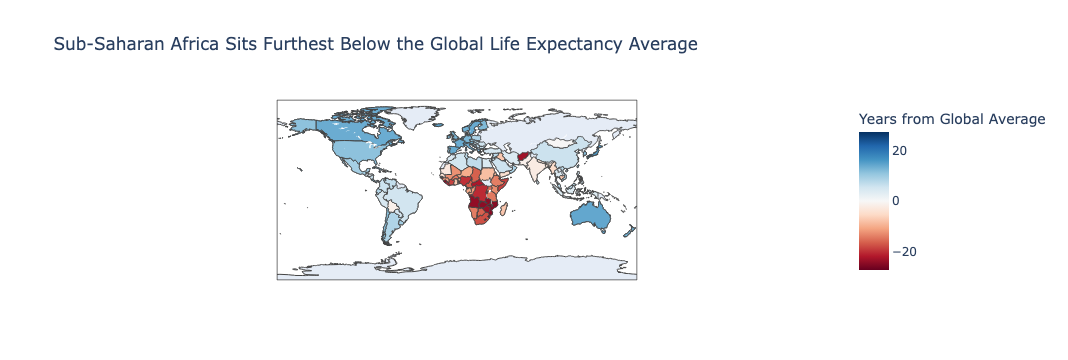

In [1]:
import pandas as pd
import plotly.express as px

gm_2007 = px.data.gapminder().query("year == 2007")

global_avg = gm_2007['lifeExp'].mean()

gm_2007['deviation'] = gm_2007['lifeExp'] - global_avg

fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='deviation',
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'deviation': ':.1f'
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title='Sub-Saharan Africa Sits Furthest Below the Global Life Expectancy Average'
)

fig.update_layout(
    coloraxis_colorbar_title='Years from Global Average'
)

fig.show()

{'name': 'Alabama', 'density': 94.65}


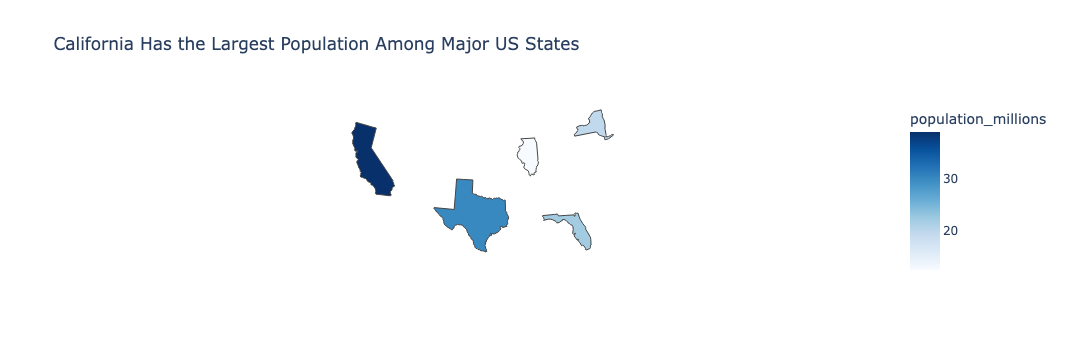

In [2]:
import pandas as pd
import plotly.express as px
import requests

geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
us_states = requests.get(geojson_url).json()

print(us_states['features'][0]['properties'])

state_data = pd.DataFrame({
    'state': ['California', 'Texas', 'Florida', 'New York', 'Illinois'],
    'population_millions': [39.0, 30.0, 22.0, 19.5, 12.5]
})

fig = px.choropleth(
    state_data,
    geojson=us_states,
    locations='state',
    featureidkey='properties.name',
    color='population_millions',
    color_continuous_scale='Blues',
    scope='usa',
    title='California Has the Largest Population Among Major US States'
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()